# Instalasi dan Import Library


In [ ]:
!pip install google_play_scraper pandas numpy matplotlib seaborn textblob nltk Sastrawi scikit-learn emoji

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google_play_scraper import reviews, Sort

# Import NLTK sesuai arahan dosen
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Pengaturan visualisasi
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 8)

# Download requirements NLTK
nltk.download('gutenberg', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

# Data Collection (Scraping dengan Sampling)

Catatan: Kita batasi 50.000 ulasan terbaru. Secara ilmu Data Science, 50 ribu sampel sudah sangat merepresentasikan populasi aplikasi, dan hanya butuh waktu beberapa detik untuk diunduh.

In [ ]:
app_id = 'ovo.id'

print(f"Mulai mengambil sampel data ulasan {app_id}...")
app_reviews, _ = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=50000 # Tetap gunakan limit ini agar tidak run berjam-jam
)

df_reviews = pd.DataFrame(app_reviews)
print(f"Total ulasan terkumpul: {df_reviews.shape[0]} baris")

def mask_username(username):
    if pd.isna(username): return username
    username = str(username)
    if len(username) <= 4: return "*" * len(username)
    return username[:2] + "*" * (len(username)-4) + username[-2:]

df_reviews['userName'] = df_reviews['userName'].apply(mask_username)
df_reviews.to_csv("app_reviews_raw.csv", index=False)
df_reviews.head()

Mulai mengambil sampel data ulasan ovo.id...
Total ulasan terkumpul: 50000 baris


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,135c967c-7077-4453-bf03-74438ab6cdfe,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi jelek banget costumer service gak bis...,1,0,None,2026-03-01 16:33:29,None,NaT,None
1,5c69b132-1b5b-4394-a7b2-5e19b01f38f0,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,gw top up ga masuk pdhal notifny msuk,1,0,3.154.0,2026-03-01 16:23:23,None,NaT,3.154.0
2,3d59a2c2-cb6f-4961-9d4f-76cdaa2e7582,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,diminta update sering,1,1,None,2026-03-01 15:47:48,None,NaT,None
3,a3de5fed-b47a-4cf6-baab-935e57164a54,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,3.44.0,2026-03-01 15:42:31,None,NaT,3.44.0
4,96d5c996-83e7-4b3d-8910-10f83192726a,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,kesel banget padahal pin scurity dy ketik bene...,1,0,3.154.0,2026-03-01 15:35:52,None,NaT,3.154.0


# Data Preprocessing (NLTK Tokenize + Fast Caching)
Kita menggunakan Vectorized String dan Caching Kata untuk menghindari Sastrawi memproses kata yang sama berulang-ulang.

In [ ]:
print("Mulai Preprocessing...")
df_clean = df_reviews.copy()

# 1. Lowercasing & 2. Punctuation Removal
print("-> Lowercasing & Membersihkan Tanda Baca...")
df_clean['content'] = df_clean['content'].astype(str).str.lower()
df_clean['content'] = df_clean['content'].str.replace(r'[^\w\s]', ' ', regex=True)
df_clean['content'] = df_clean['content'].str.replace(r'\s+', ' ', regex=True).str.strip()

# 3. Tokenization
print("-> Tokenisasi dengan NLTK word_tokenize...")
df_clean['tokens'] = df_clean['content'].apply(word_tokenize)

# 4. Slang Normalization
print("-> Normalisasi Kata Gaul...")
slang_dict = {
    "ga": "tidak", "gak": "tidak", "nggak": "tidak", "gabisa": "tidak bisa",
    "yg": "yang", "tp": "tapi", "krn": "karena", "karna": "karena",
    "dgn": "dengan", "dr": "dari", "jg": "juga", "jd": "jadi",
    "sdh": "sudah", "blm": "belum", "msh": "masih", "lg": "lagi",
    "klo": "kalau", "kalo": "kalau", "gw": "saya", "ak": "saya",
    "bgt": "banget", "skrg": "sekarang", "trs": "terus", "aja": "saja",
    "emg": "memang", "sampe": "sampai", "knp": "kenapa", "gmn": "bagaimana",
    "udah": "sudah", "udh": "sudah", "bikin": "membuat", "nyoba": "coba",
    "oke": "baik", "makasih": "terima kasih", "mantep": "mantap", "gpp": "tidak apa-apa",
    "tf": "transfer", "trf": "transfer", "trx": "transaksi", "rek": "rekening",
    "apk": "aplikasi", "app": "aplikasi", "eror": "error", "lemot": "lambat"
}

def normalize_slang(tokens):
    if not isinstance(tokens, list): return []
    res = []
    for t in tokens:
        val = slang_dict.get(t, t)
        res.extend(val.split()) if " " in val else res.append(val)
    return res

df_clean['tokens'] = df_clean['tokens'].apply(normalize_slang)

# 5. Stopword Removal
print("-> Menghapus Stopwords...")
id_stopwords = set(StopWordRemoverFactory().get_stop_words())
en_stopwords = set(stopwords.words('english'))
all_stopwords = id_stopwords | en_stopwords

df_clean['tokens'] = df_clean['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in all_stopwords and len(w) > 1]
)

# 6. Stemming Caching Super Cepat
print("-> Proses Stemming...")
indo_stemmer = StemmerFactory().create_stemmer()

unique_words = set(word for tokens in df_clean['tokens'] for word in tokens)
print(f"   Ditemukan {len(unique_words)} kata unik. Sedang memproses (harap tunggu +- 1 menit)...")

stem_cache = {word: indo_stemmer.stem(word) for word in unique_words}

df_clean['tokens'] = df_clean['tokens'].apply(
    lambda tokens: [stem_cache.get(w, w) for w in tokens if len(stem_cache.get(w, w)) > 1]
)

print("Preprocessing selesai!")
df_clean[['content', 'tokens']].head()

Mulai Preprocessing...
-> Lowercasing & Membersihkan Tanda Baca...
-> Tokenisasi dengan NLTK word_tokenize...
-> Normalisasi Kata Gaul...
-> Menghapus Stopwords...
-> Proses Stemming...
   Ditemukan 22594 kata unik. Sedang memproses (harap tunggu +- 1 menit)...
Preprocessing selesai!


,content,tokens
0,aplikasi jelek banget costumer service gak bis...,"[aplikasi, jelek, banget, costumer, service, k..."
1,gw top up ga masuk pdhal notifny msuk,"[top, masuk, pdhal, notifny, msuk]"
2,diminta update sering,"[minta, update, sering]"
3,mantap,[mantap]
4,kesel banget padahal pin scurity dy ketik bene...,"[kesel, banget, padahal, pin, scurity, dy, ket..."


# Exploratory Data Analysis (EDA) & Visualisasi
Menggunakan Pandas explode() untuk menghitung frekuensi kata agar sangat efisien di RAM dan mencegah komputer lag/crash.

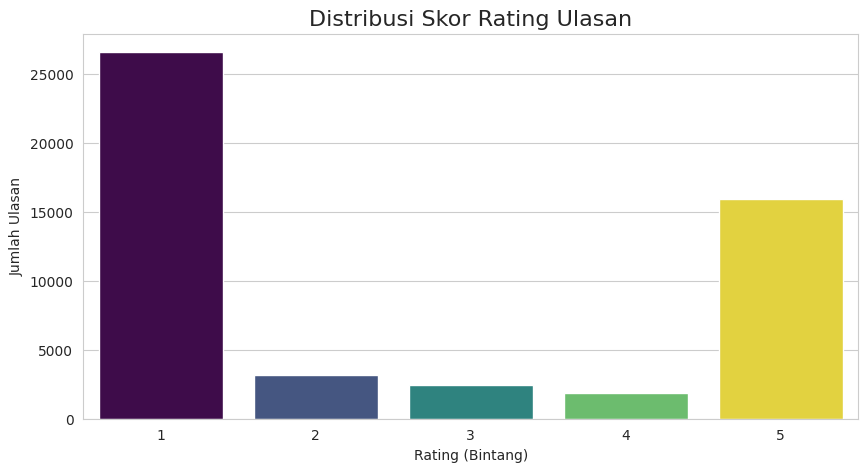

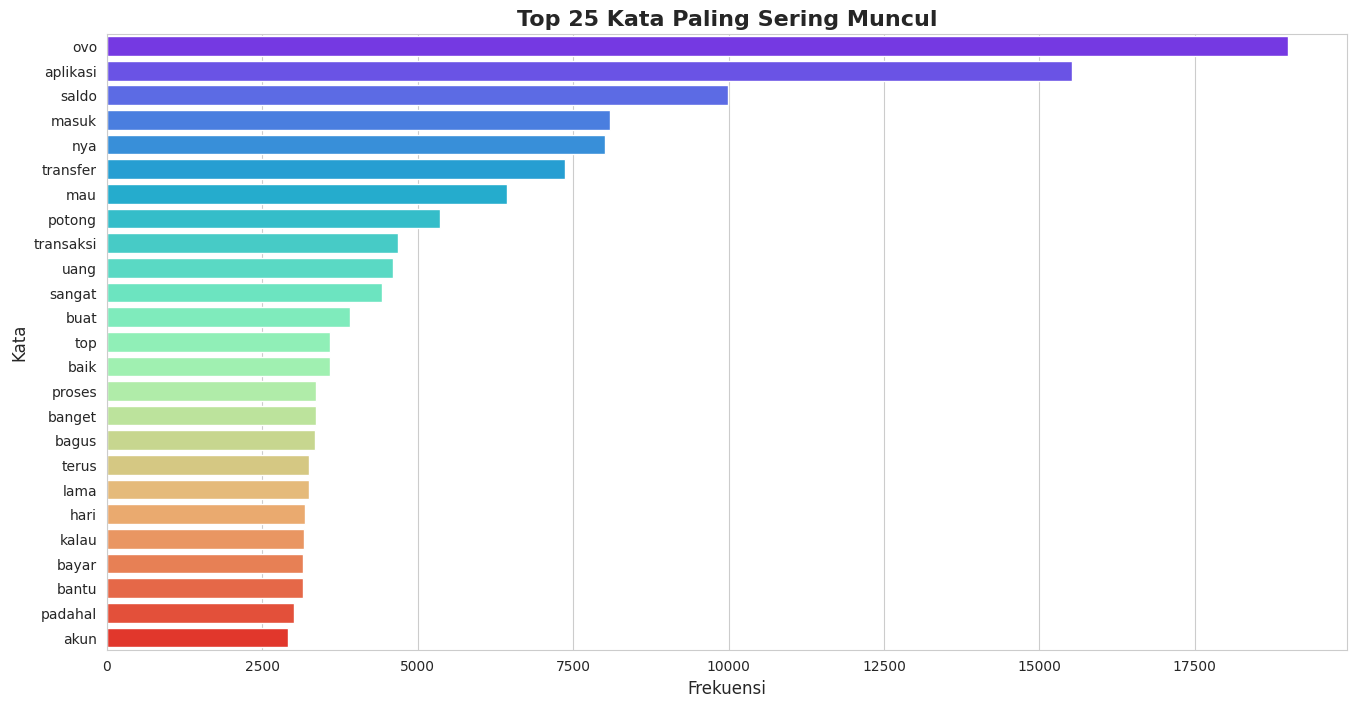

In [ ]:
# 1. Visualisasi Distribusi Skor (Rating Bintang)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='score', palette='viridis', hue='score', legend=False)
plt.title("Distribusi Skor Rating Ulasan", fontsize=16)
plt.xlabel("Rating (Bintang)")
plt.ylabel("Jumlah Ulasan")
plt.show()

# 2. Visualisasi Frekuensi Kata Terbanyak
word_counts = df_clean['tokens'].explode().value_counts().head(25)
words_df = pd.DataFrame({'word': word_counts.index, 'count': word_counts.values})

plt.figure(figsize=(16, 8))
ax = sns.barplot(data=words_df, x="count", y="word", hue="word", palette="rainbow", legend=False)
ax.set_title('Top 25 Kata Paling Sering Muncul', fontsize=16, fontweight='bold')
ax.set_xlabel('Frekuensi', fontsize=12)
ax.set_ylabel('Kata', fontsize=12)
plt.show()